### Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

# XAI
import shap
from lime import lime_tabular

# Models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Settings
os.chdir('/Users/cirrus/Desktop/PMOS_PROJECT/notebook')
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

print('✅ All libraries imported')

✅ All libraries imported


### Cell 2 — Load Data & Models

In [2]:
# Load processed data
df = pd.read_csv('../data/processed/pmos_eda_clean.csv')
df.columns = df.columns.str.strip()

# Load features and models
with open('artifacts/final_features.pkl', 'rb') as f:
    final_features = pickle.load(f)

with open('artifacts/best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

with open('artifacts/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load train/test data
X_train = pd.read_csv('artifacts/X_train.csv')
X_test  = pd.read_csv('artifacts/X_test.csv')
y_train = pd.read_csv('artifacts/y_train.csv').squeeze()
y_test  = pd.read_csv('artifacts/y_test.csv').squeeze()

X = df[final_features].fillna(df[final_features].median())
y = df['PCOS (Y/N)']

print('✅ Data and models loaded')
print(f'   Features  : {len(final_features)}')
print(f'   Patients  : {len(df)}')
print(f'   Best model: Logistic Regression')
print(f'\nFeatures: {final_features}')

✅ Data and models loaded
   Features  : 13
   Patients  : 541
   Best model: Logistic Regression

Features: ['Follicle No. (R)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Follicle No. (L)', 'Pimples(Y/N)', 'LH(mIU/mL)', 'Fast food (Y/N)', 'AMH(ng/mL)', 'Marraige Status (Yrs)', 'I   beta-HCG(mIU/mL)', 'PRG(ng/mL)']


### Cell 3 — SHAP Global Explanation

In [3]:
# Alternative SHAP bar plot — works better in VS Code
shap_importance = pd.DataFrame({
    'Feature': final_features,
    'Mean SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean SHAP', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if i >= len(shap_importance)-3 
          else '#3498db' 
          for i in range(len(shap_importance))]
plt.barh(shap_importance['Feature'], 
         shap_importance['Mean SHAP'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Mean |SHAP Value| (Average Impact on Prediction)')
plt.title('SHAP Feature Importance — PMOS Diagnosis',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/B7_01_shap_importance.png', bbox_inches='tight')
plt.show()

print('\n=== SHAP FEATURE RANKING ===')
print(shap_importance.sort_values('Mean SHAP', 
      ascending=False).to_string(index=False))

NameError: name 'shap_values' is not defined

### Now Cell 4 — Individual Patient SHAP Explanation! 🚀

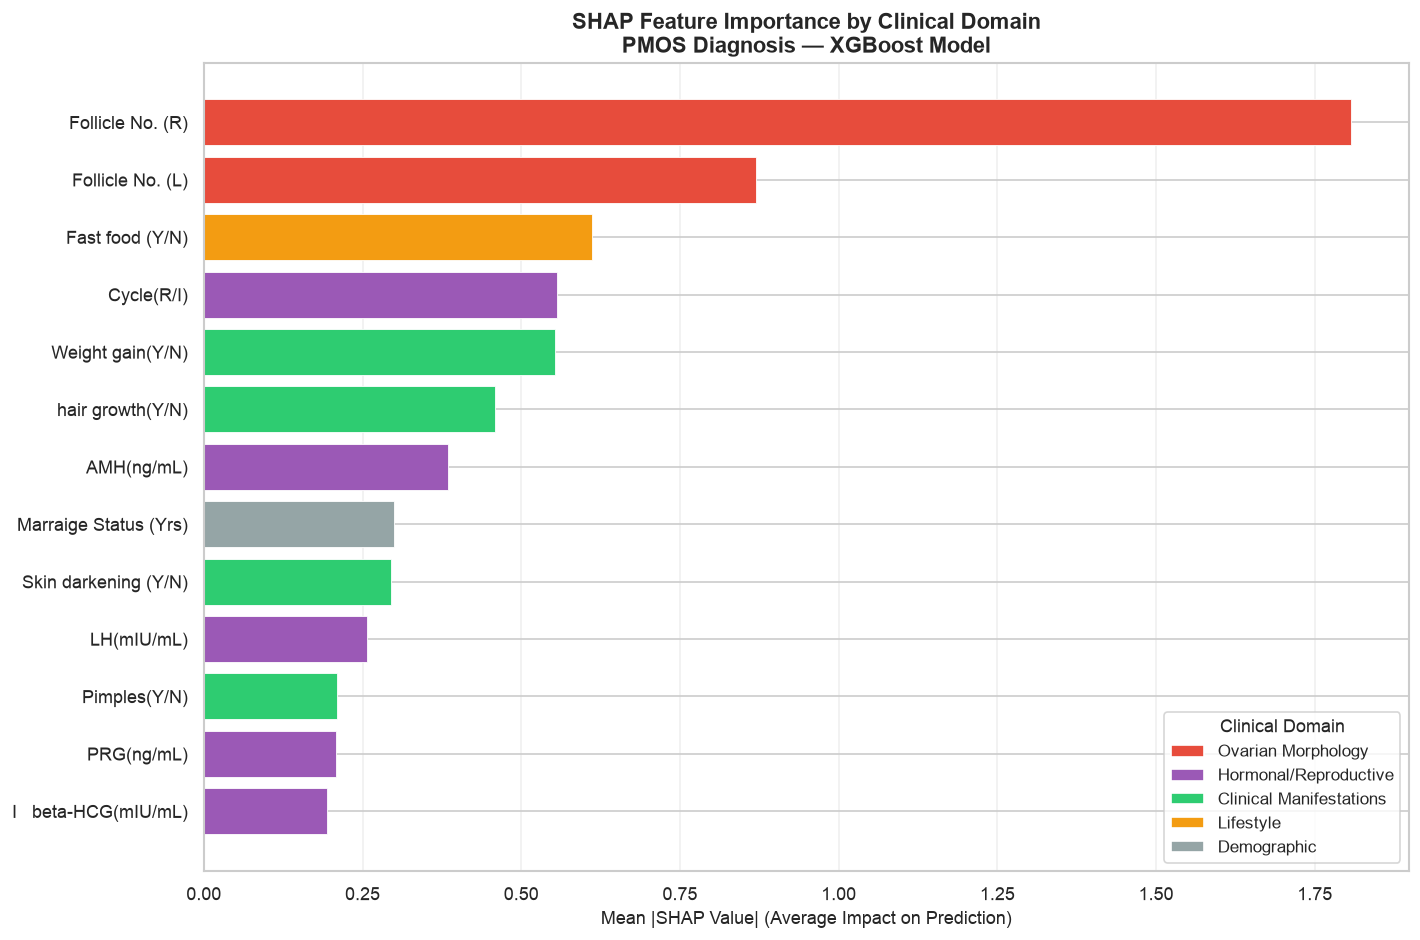

=== SHAP IMPORTANCE BY CLINICAL DOMAIN ===

Ovarian Morphology:
  Follicle No. (R)              : 1.808
  Follicle No. (L)              : 0.870

Hormonal/Reproductive:
  Cycle(R/I)                    : 0.557
  AMH(ng/mL)                    : 0.385
  LH(mIU/mL)                    : 0.257
  PRG(ng/mL)                    : 0.208
  I   beta-HCG(mIU/mL)          : 0.193

Clinical Manifestations:
  Weight gain(Y/N)              : 0.553
  hair growth(Y/N)              : 0.459
  Skin darkening (Y/N)          : 0.295
  Pimples(Y/N)                  : 0.210

Lifestyle:
  Fast food (Y/N)               : 0.612

Demographic:
  Marraige Status (Yrs)         : 0.299



In [ ]:
# Grouped SHAP importance
shap_df = pd.DataFrame({
    'Feature'  : final_features,
    'Mean SHAP': np.abs(shap_values).mean(axis=0)
})

# Assign clinical groups
group_map = {
    'Follicle No. (R)'       : 'Ovarian Morphology',
    'Follicle No. (L)'       : 'Ovarian Morphology',
    'AMH(ng/mL)'             : 'Hormonal/Reproductive',
    'LH(mIU/mL)'             : 'Hormonal/Reproductive',
    'PRG(ng/mL)'             : 'Hormonal/Reproductive',
    'I   beta-HCG(mIU/mL)'  : 'Hormonal/Reproductive',
    'Cycle(R/I)'             : 'Hormonal/Reproductive',
    'Weight gain(Y/N)'       : 'Clinical Manifestations',
    'hair growth(Y/N)'       : 'Clinical Manifestations',
    'Skin darkening (Y/N)'   : 'Clinical Manifestations',
    'Pimples(Y/N)'           : 'Clinical Manifestations',
    'Fast food (Y/N)'        : 'Lifestyle',
    'Marraige Status (Yrs)'  : 'Demographic',
}

group_colors = {
    'Ovarian Morphology'    : '#e74c3c',
    'Hormonal/Reproductive' : '#9b59b6',
    'Clinical Manifestations': '#2ecc71',
    'Lifestyle'             : '#f39c12',
    'Demographic'           : '#95a5a6',
}

shap_df['Group'] = shap_df['Feature'].map(group_map)
shap_df['Color'] = shap_df['Group'].map(group_colors)
shap_df = shap_df.sort_values('Mean SHAP', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(shap_df['Feature'], shap_df['Mean SHAP'],
               color=shap_df['Color'],
               edgecolor='white', linewidth=0.5)

# Add group legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=group)
    for group, color in group_colors.items()
]
ax.legend(handles=legend_elements, loc='lower right',
          fontsize=10, title='Clinical Domain',
          title_fontsize=11)

ax.set_xlabel('Mean |SHAP Value| (Average Impact on Prediction)',
              fontsize=11)
ax.set_title('SHAP Feature Importance by Clinical Domain\nPMOS Diagnosis — XGBoost Model',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/plots/B7_01_shap_grouped.png', bbox_inches='tight')
plt.show()

# Print grouped summary
print('=== SHAP IMPORTANCE BY CLINICAL DOMAIN ===\n')
for group in group_colors.keys():
    group_df = shap_df[shap_df['Group'] == group].sort_values(
                'Mean SHAP', ascending=False)
    if len(group_df) > 0:
        print(f'{group}:')
        for _, row in group_df.iterrows():
            print(f'  {row["Feature"]:30s}: {row["Mean SHAP"]:.3f}')
        print()

Clear PMOS+ patients (prob > 0.8): 26
Using patient index: 3


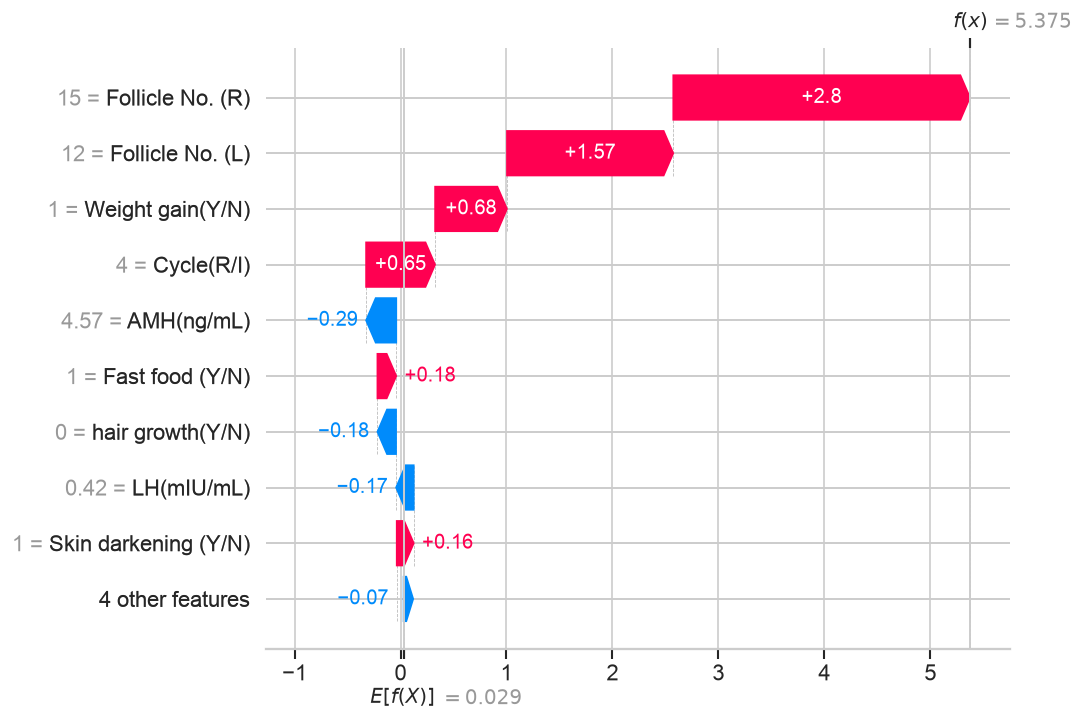

In [ ]:
# Find a clearly PMOS+ patient with high confidence
y_probs = xgb_model.predict_proba(X_test)[:, 1]
clear_pmos = np.where((y_test.values == 1) & (y_probs > 0.8))[0]
print(f'Clear PMOS+ patients (prob > 0.8): {len(clear_pmos)}')
print(f'Using patient index: {clear_pmos[0]}')
patient_idx = clear_pmos[0]

shap_explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[patient_idx].values,
    feature_names=final_features
)

shap.waterfall_plot(shap_explanation, show=True)

In [6]:
import matplotlib
fig = plt.gcf()
fig.savefig('outputs/plots/B7_02_shap_waterfall.png', 
            bbox_inches='tight', dpi=120)
print('✅ Waterfall plot saved')

✅ Waterfall plot saved


<Figure size 768x576 with 0 Axes>